In [17]:
import os
import cv2
import sys
import numpy as np
sys.path.append('practicum_work/src')
from dataset.eda import missed_labels, class_distribution, size_distribution
from dataset.coco import generate_coco_dataset
from dataset.label import generate_labeled_dataset

def find_train_unlabeled(folder: str, img_dir: str, lbl_dir: str):
    img_dir = os.path.join(img_dir, folder)
    label_dir = os.path.join(lbl_dir, folder)
    imgs = os.listdir(img_dir)
    for i in range(len(imgs)):
        file_name = os.path.splitext(imgs[i])[0] + '.png'
        label_path = os.path.join(label_dir, file_name)
        if not os.path.exists(label_path):
            print('File {} does not exist.'.format(label_path))

base_img_dir = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\base\img'
base_lbl_dir = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\base\labels'

for folder in ['train', 'test', 'val']:
    find_train_unlabeled(folder, base_img_dir, base_lbl_dir)

In [18]:
base_dir = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\base'
output_root = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\labeled'
for split in ['train', 'val', 'test']:
    img_path = os.path.join(base_dir, 'img', split)
    lbl_path = os.path.join(base_dir, 'labels', split)
    output_path = os.path.join(output_root, split)
    generate_labeled_dataset(img_path, lbl_path, output_path, {1: [255, 0, 0], 2: [0, 255, 0]})

Generating colored labeled images in C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\labeled\train...


100%|██████████| 200/200 [00:01<00:00, 172.36it/s]


Generating colored labeled images in C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\labeled\val...


100%|██████████| 120/120 [00:00<00:00, 189.88it/s]


Generating colored labeled images in C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\labeled\test...


100%|██████████| 120/120 [00:02<00:00, 54.36it/s]


# Exploratory Data Analysis (EDA)

No missing labels found.


100%|██████████| 200/200 [00:00<00:00, 1344.81it/s]


Class distribution (pixel counts):
background: 11908826 pixels
cat: 653268 pixels
dog: 545106 pixels


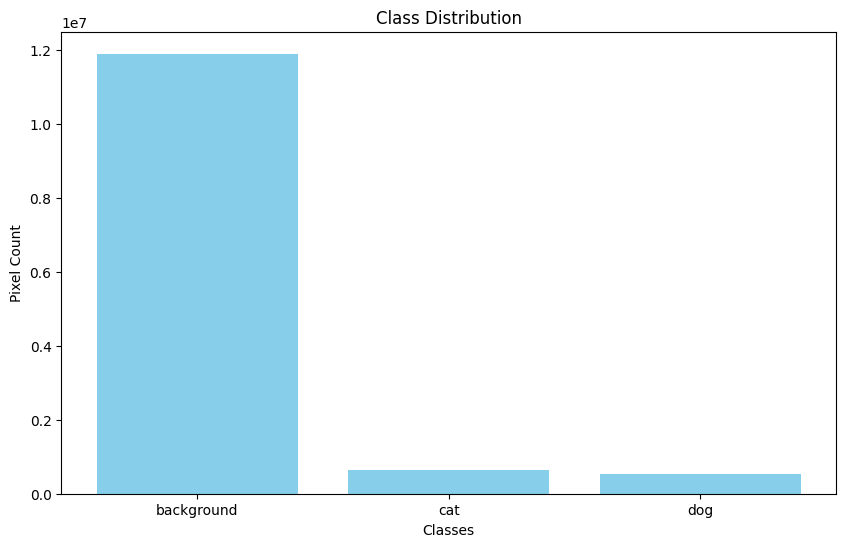

100%|██████████| 200/200 [00:00<00:00, 1962.55it/s]

Average size: 256.00x256.00
Min size: 256x256
Max size: 256x256


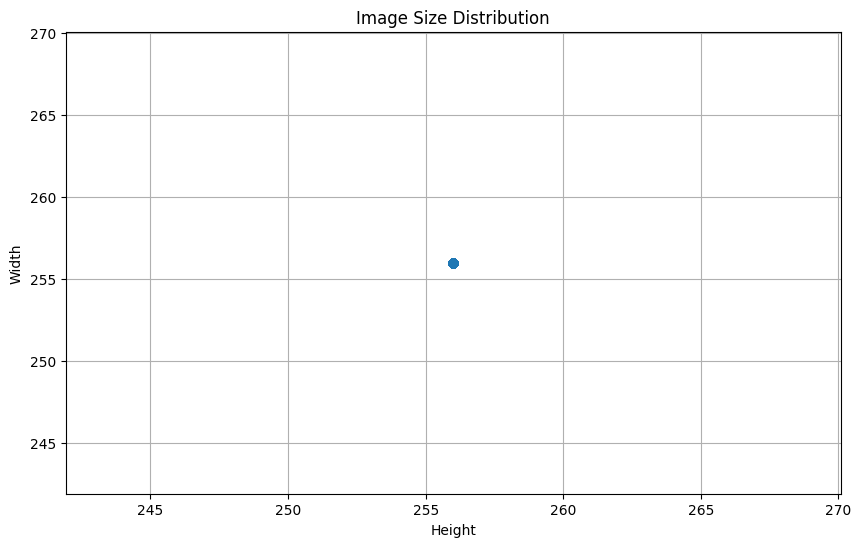

array([[256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256, 256],
       [256,

In [19]:
categories = ['background', 'cat', 'dog']
img_path = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\base\img\train'
lbl_path = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\base\labels\train'

missed_labels(img_path, lbl_path)
class_distribution(lbl_path, categories=categories)
size_distribution(img_path)

# COCO Annotations Preparation

In [20]:
output_folder = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\coco'
base_dir = r'C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\base'

for split in ['train', 'val', 'test']:
    img_split = os.path.join(base_dir, 'img', split)
    lbl_split = os.path.join(base_dir, 'labels', split)
    output_split_folder = os.path.join(output_folder, split)
    os.makedirs(output_split_folder, exist_ok=True)
    output_json = os.path.join(output_split_folder, 'annotations.json')
    generate_coco_dataset(img_split, lbl_split, output_json, categories=['background', 'class1', 'class2'])

Generating COCO dataset for 200 images...


100%|██████████| 200/200 [00:00<00:00, 881.79it/s]


Saved 233 annotations to C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\coco\train\annotations.json
Generating COCO dataset for 120 images...


100%|██████████| 120/120 [00:00<00:00, 906.07it/s]


Saved 129 annotations to C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\coco\val\annotations.json
Generating COCO dataset for 120 images...


100%|██████████| 120/120 [00:00<00:00, 897.06it/s]

Saved 124 annotations to C:\Users\igors\Projects\mmsegmentation-benchmarking\practicum_work\dataset\coco\test\annotations.json

# Experiment 1: DeepLabV3+ ResNet-50 D8

In [21]:
# !python tools/train.py \
#     configs/experiments/deeplabv3plus_r50_d8_20k_coco_animals.py \
#     --work-dir ./practicum_work/experiments/deeplabv3plus_r50_d8 \
#     --amp

In [22]:
!python tools/test.py \
    configs/experiments/deeplabv3plus_r50_d8_20k_coco_animals.py \
    practicum_work/experiments/deeplabv3plus_r50_d8/iter_20000.pth

03/24 10:09:04 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1242108944
    GPU 0: NVIDIA GeForce RTX 3060 Ti
    CUDA_HOME: None
    MSVC: Microsoft (R) C/C++ Optimizing Compiler Version 19.44.35219 for x64
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;

C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\backbones\resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\engine\hooks\visuali

# Experiment 2: DeepLabV3+ ResNet-50 D16

In [23]:
# !python tools/train.py \
#     configs/experiments/deeplabv3plus_r50_d16_20k_coco_animals.py \
#     --work-dir ./practicum_work/experiments/deeplabv3plus_r50_d16 \
#     --amp

In [24]:
!python tools/test.py \
    configs/experiments/deeplabv3plus_r50_d16_20k_coco_animals.py \
    practicum_work/experiments/deeplabv3plus_r50_d16/iter_20000.pth

03/24 10:09:45 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 943808202
    GPU 0: NVIDIA GeForce RTX 3060 Ti
    CUDA_HOME: None
    MSVC: Microsoft (R) C/C++ Optimizing Compiler Version 19.44.35219 for x64
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-

C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\backbones\resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\engine\hooks\visuali

# Experiment 3: DeepLabV3+ ResNet-101 D16

In [25]:
# !python tools/train.py \
#     configs/experiments/deeplabv3plus_r101_d16_20k_coco_animals.py \
#     --work-dir ./practicum_work/experiments/deeplabv3plus_r101_d16 \
#     --amp

In [26]:
!python tools/test.py \
    configs/experiments/deeplabv3plus_r101_d16_20k_coco_animals.py \
    practicum_work/experiments/deeplabv3plus_r101_d16/iter_20000.pth

03/24 10:10:20 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 32430608
    GPU 0: NVIDIA GeForce RTX 3060 Ti
    CUDA_HOME: None
    MSVC: Microsoft (R) C/C++ Optimizing Compiler Version 19.44.35219 for x64
    GCC: n/a
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm_50;-g

C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\backbones\resnet.py:431: UserWarning: DeprecationWarning: pretrained is a deprecated, please use "init_cfg" instead
  warnings.warn('DeprecationWarning: pretrained is a deprecated, '
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(
C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\engine\hooks\visuali

# Results Analysis: Best DeepLabv3+ - ResNet50 - d8

In [34]:
!python practicum_work/src/analysis/dump_model_predictions.py \
    configs/experiments/deeplabv3plus_r50_d8_20k_coco_animals.py \
    practicum_work/experiments/deeplabv3plus_r50_d8/iter_20000.pth \
    practicum_work/dataset/base/img/test \
    practicum_work/experiments/deeplabv3plus_r50_d8/preds_test

Loads checkpoint by local backend from path: practicum_work/experiments/deeplabv3plus_r50_d8/iter_20000.pth
Running inference on 120 images...
Predictions dumped to practicum_work/experiments/deeplabv3plus_r50_d8/preds_test


C:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning: Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.
  warnings.warn(

100%|██████████| 120/120 [00:58<00:00,  2.05it/s]


In [37]:
!python practicum_work/src/analysis/save_best_on_worst_based_on_individual_dice_score.py \
    practicum_work/experiments/deeplabv3plus_r50_d8/preds_test \
    practicum_work/dataset/base/labels/test \
    practicum_work/dataset/base/img/test \
    practicum_work/experiments/deeplabv3plus_r50_d8/best_worst_test \
    --num-classes 3

Calculating Dice scores...
Saving worst 5 examples...
Saving best 5 examples...


In [41]:
import optuna
import pandas as pd
from IPython.display import display

from mmengine.config import Config
from mmengine.runner import Runner
from mmengine.hooks import Hook
from mmseg.registry import HOOKS

# ==========================================
# 1. ОПРЕДЕЛЯЕМ ХУК БЕЗ РЕГИСТРАЦИИ В CONFIG
# ==========================================
class OptunaPruningHook(Hook):
    def __init__(self, trial, metric='val/mDice', interval=1):
        self.trial = trial
        self.metric = metric

    def after_val_epoch(self, runner, metrics=None):
        # Забираем метрику для Optuna
        if metrics is not None and self.metric in metrics:
            current_score = metrics[self.metric]
        else:
            try:
                current_score = runner.message_hub.get_scalar(self.metric).current()
            except:
                return # Если метрики еще нет, пропускаем

        step = runner.epoch if runner.train_loop.by_epoch else runner.iter
        self.trial.report(current_score, step)

        # Если эксперимент идет хуже других — обрубаем его
        if self.trial.should_prune():
            raise optuna.TrialPruned(f"Trial {self.trial.number} pruned at step {step}")


# ==========================================
# 2. ФУНКЦИЯ ПОДБОРА ПАРАМЕТРОВ
# ==========================================
def objective(trial):
    # --- Выбор архитектуры из 5 доступных ---
    arch_config = trial.suggest_categorical('config', [
        'configs/experiments/deeplabv3plus_r50_d8_20k_coco_animals.py',
        'configs/experiments/pspnet_r50_d8_20k_coco_animals.py',
        'configs/experiments/fcn_r50_d8_20k_coco_animals.py',
        'configs/experiments/upernet_r50_20k_coco_animals.py',
        'configs/experiments/segformer_mit-b0_20k_coco_animals.py'
    ])
    
    # --- Подбор гиперпараметров ---
    lr = trial.suggest_float('lr', 1e-4, 1e-2, log=True)
    weight_decay = trial.suggest_float('weight_decay', 1e-5, 1e-3, log=True)
    prob_flip = trial.suggest_float('prob_flip', 0.0, 1.0)
    
    # Загружаем конфиг
    cfg = Config.fromfile(arch_config)
    cfg.optim_wrapper.optimizer.lr = lr
    cfg.optim_wrapper.optimizer.weight_decay = weight_decay
    
    # Меняем вероятность RandomFlip
    if hasattr(cfg, 'train_pipeline'):
        for transform in cfg.train_pipeline:
            if transform.get('type') == 'RandomFlip':
                transform['prob'] = prob_flip
    
    # Указываем директорию триала
    cfg.work_dir = f'./work_dirs/optuna_study/trial_{trial.number}'
    
    # Настройки для ускорения перебора
    cfg.train_cfg.max_iters = 6000
    cfg.train_cfg.val_interval = 2000
    cfg.default_hooks.checkpoint.interval = 6000
    
    # === ОБУЧАЕМ И ПОЛУЧАЕМ ОЦЕНКУ ===
    try:
        runner = Runner.from_cfg(cfg)
        
        # РЕГИСТРИРУЕМ ХУК ВНУТРЬ РАННЕРА
        # Это позволяет передать объект trial напрямую, не ломая конфиг
        optuna_hook = OptunaPruningHook(trial=trial, metric='val/mDice')
        runner.register_hook(optuna_hook, priority='LOWEST')
        
        runner.train()
        
        # Получаем финальный mDice
        val_metrics = runner.val_loop.run()
        return val_metrics['mDice']
        
    except optuna.TrialPruned as e:
        # Успешно обрубили плохой эксперимент
        raise e
    except Exception as e:
        print(f"Эксперимент №{trial.number} сломался с ошибкой: {e}")
        return 0.0


# ==========================================
# 3. ЗАПУСК ИССЛЕДОВАНИЯ
# ==========================================
study = optuna.create_study(
    study_name='mmseg_benchmark_tuner',
    direction='maximize',
    pruner=optuna.pruners.MedianPruner(n_warmup_steps=2000)
)

print("Начинаю перебор гиперпараметров для 5 архитектур (15 попыток)...")
study.optimize(objective, n_trials=15)

# ==========================================
# 4. ВЫВОД РЕЗУЛЬТАТОВ
# ==========================================
print("\n🏆 ЛУЧШИЕ ПАРАМЕТРЫ:")
print(study.best_params)

df = study.trials_dataframe()
cols = ['number', 'value', 'state', 'params_config', 'params_lr', 'params_prob_flip', 'params_weight_decay']
df = df[cols].sort_values(by='value', ascending=False)
display(df)


[I 2026-03-24 10:58:25,824] A new study created in memory with name: mmseg_benchmark_tuner


Начинаю перебор гиперпараметров для 5 архитектур (15 попыток)...
03/24 10:58:27 - mmengine - INFO - 
------------------------------------------------------------
System environment:
    sys.platform: win32
    Python: 3.10.0 (tags/v3.10.0:b494f59, Oct  4 2021, 19:00:18) [MSC v.1929 64 bit (AMD64)]
    CUDA available: True
    MUSA available: False
    numpy_random_seed: 1240126994
    GPU 0: NVIDIA GeForce RTX 3060 Ti
    CUDA_HOME: None
    MSVC: n/a, reason: fileno
    PyTorch: 2.0.0+cu118
    PyTorch compiling details: PyTorch built with:
  - C++ Version: 199711
  - MSVC 193431937
  - Intel(R) Math Kernel Library Version 2020.0.2 Product Build 20200624 for Intel(R) 64 architecture applications
  - Intel(R) MKL-DNN v2.7.3 (Git Hash 6dbeffbae1f23cbbeae17adb7b5b13f1f37c080e)
  - OpenMP 2019
  - LAPACK is enabled (usually provided by MKL)
  - CPU capability usage: AVX2
  - CUDA Runtime 11.8
  - NVCC architecture flags: -gencode;arch=compute_37,code=sm_37;-gencode;arch=compute_50,code=sm

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\models\losses\cross_entropy_loss.py:250: UserWarning:

Default ``avg_non_ignore`` is False, if you would like to ignore the certain label and average loss over non-ignore labels, which is the same with PyTorch official cross_entropy, set ``avg_non_ignore=True``.

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\engine\hooks\visualization_hook.py:60: UserWarning:

The draw is False, it means that the hook for visualization will not take effect. The results will NOT be visualized or stored.

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\datasets\transforms\loading.py:84: UserWarning:

`reduce_zero_label` will be deprecated, if you would like to ignore the zero label, please set `reduce_zero_label=True` when dataset initialized

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\datasets\transforms\loading.py:84: UserWarning:

`reduce_zero_label` will be deprecated, if you would like to ignore the zero l

03/24 10:58:37 - mmengine - WARNING - "FileClient" will be deprecated in future. Please use io functions in https://mmengine.readthedocs.io/en/latest/api/fileio.html#file-io
03/24 10:58:37 - mmengine - WARNING - "HardDiskBackend" is the alias of "LocalBackend" and the former will be deprecated in future.
03/24 10:58:37 - mmengine - INFO - Checkpoints will be saved to c:\Users\igors\Projects\mmsegmentation-benchmarking\work_dirs\optuna_study\trial_0.
03/24 10:58:44 - mmengine - INFO - Exp name: segformer_mit-b0_20k_coco_animals_20260324_105825
03/24 10:58:44 - mmengine - INFO - Iter(train) [  50/6000]  lr: 2.0028e-03  eta: 0:14:31  time: 0.0617  data_time: 0.0033  memory: 914  loss: 0.4649  decode.loss_ce: 0.3731  decode.loss_dice: 0.0919  decode.acc_seg: 90.1642
03/24 10:58:47 - mmengine - INFO - Iter(train) [ 100/6000]  lr: 1.9985e-03  eta: 0:10:13  time: 0.0619  data_time: 0.0019  memory: 529  loss: 0.4123  decode.loss_ce: 0.3274  decode.loss_dice: 0.0849  decode.acc_seg: 90.9527
03/

[I 2026-03-24 11:00:49,486] Trial 0 finished with value: 0.0 and parameters: {'config': 'configs/experiments/segformer_mit-b0_20k_coco_animals.py', 'lr': 0.002007015521952182, 'weight_decay': 2.373361550053406e-05, 'prob_flip': 0.2975331062904374}. Best is trial 0 with value: 0.0.


...

03/24 11:12:14 - mmengine - INFO - Distributed training is not used, all SyncBatchNorm (SyncBN) layers in the model will be automatically reverted to BatchNormXd layers if they are used.
03/24 11:12:14 - mmengine - INFO - Hooks will be executed in the following order:
before_run:
(VERY_HIGH   ) RuntimeInfoHook                    
(BELOW_NORMAL) LoggerHook                         
 -------------------- 
before_train:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(VERY_LOW    ) CheckpointHook                     
 -------------------- 
before_train_epoch:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
(NORMAL      ) DistSamplerSeedHook                
 -------------------- 
before_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                    
(NORMAL      ) IterTimerHook                      
 -------------------- 
after_train_iter:
(VERY_HIGH   ) RuntimeInfoHook                

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\engine\hooks\visualization_hook.py:60: UserWarning:

The draw is False, it means that the hook for visualization will not take effect. The results will NOT be visualized or stored.

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\datasets\transforms\loading.py:84: UserWarning:

`reduce_zero_label` will be deprecated, if you would like to ignore the zero label, please set `reduce_zero_label=True` when dataset initialized

c:\Users\igors\Projects\mmsegmentation-benchmarking\mmseg\datasets\transforms\loading.py:84: UserWarning:

`reduce_zero_label` will be deprecated, if you would like to ignore the zero label, please set `reduce_zero_label=True` when dataset initialized



03/24 11:12:15 - mmengine - INFO - load model from: open-mmlab://resnet50_v1c
03/24 11:12:15 - mmengine - INFO - Loads checkpoint by openmmlab backend from path: open-mmlab://resnet50_v1c
03/24 11:12:21 - mmengine - WARNING - The model and loaded state dict do not match exactly

unexpected key in source state_dict: fc.weight, fc.bias

03/24 11:12:21 - mmengine - WARNING - "FileClient" will be deprecated in future. Please use io functions in https://mmengine.readthedocs.io/en/latest/api/fileio.html#file-io
03/24 11:12:21 - mmengine - INFO - Checkpoints will be saved to c:\Users\igors\Projects\mmsegmentation-benchmarking\work_dirs\optuna_study\trial_3.
03/24 11:12:33 - mmengine - INFO - Exp name: upernet_r50_20k_coco_animals_20260324_111130
03/24 11:12:33 - mmengine - INFO - Iter(train) [  50/6000]  lr: 5.8048e-03  eta: 0:22:55  time: 0.1550  data_time: 0.0026  memory: 5659  loss: 0.3978  decode.loss_ce: 0.1789  decode.loss_dice: 0.0503  decode.acc_seg: 95.6680  aux.loss_ce: 0.1338  aux.

[W 2026-03-24 11:13:07,386] Trial 3 failed with parameters: {'config': 'configs/experiments/upernet_r50_20k_coco_animals.py', 'lr': 0.0058174427123054056, 'weight_decay': 0.00011240099229238045, 'prob_flip': 0.5968639793789121} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "c:\Users\igors\Projects\mmsegmentation-benchmarking\.venv\lib\site-packages\optuna\study\_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "C:\Users\igors\AppData\Local\Temp\ipykernel_10116\3536629804.py", line 82, in objective
    runner.train()
  File "c:\Users\igors\Projects\mmsegmentation-benchmarking\.venv\lib\site-packages\mmengine\runner\runner.py", line 1777, in train
    model = self.train_loop.run()  # type: ignore
  File "c:\Users\igors\Projects\mmsegmentation-benchmarking\.venv\lib\site-packages\mmengine\runner\loops.py", line 289, in run
    self.run_iter(data_batch)
  File "c:\Users\igors\Projects\mmsegmentation-benchmarking

KeyboardInterrupt: 